# 02 — Calibration

Fit the baseline (status quo) model to the calibration targets:

1. **Inputs** — priors and targets, bundled into a `BayesianCompartmentalModel` (BCM).
2. **Maximum likelihood estimate** — a quick `nevergrad` search for a well-fitting parameter set,
   used to check the model can reproduce the targets and to start the chains from a sensible point.
3. **Metropolis sampling** — posterior sampling with `DEMetropolisZ`, plus the usual diagnostics
   (traces, effective sample sizes, posterior vs prior).
4. **Model fit with uncertainty** — rerun the model over posterior samples and compare credible
   intervals with the targets.

The sampling settings used below (`TEST_ANALYSIS_CONFIG`) are deliberately small so the notebook
runs quickly; switch to `DEFAULT_ANALYSIS_CONFIG` for a real calibration.

> On macOS, `cores` is set to 1 because pymc's `os.fork`-based multiprocessing can deadlock with
> JAX's threads. Increase it on Linux.


In [1]:
from time import time

import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

import tbtoy.plotting as pl
import tbtoy.runner_tools as rt
from tbtoy.config import TEST_ANALYSIS_CONFIG

analysis_config = TEST_ANALYSIS_CONFIG
analysis_config


WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


{'chains': 2,
 'cores': 1,
 'tune': 50,
 'draws': 200,
 'burn_in': 50,
 'full_runs_samples': 50}

In [2]:
params, priors, tv_params = rt.get_parameters_and_priors()
targets = rt.get_targets()

# the baseline (status quo) scenario is the one that gets calibrated
bcm = rt.build_bcm(params=params, priors=priors, targets=targets, tv_params=tv_params)

print(f"{len(priors)} calibrated parameters, {len(targets)} target series")


13 calibrated parameters, 7 target series


In [3]:
prior_summary = pd.DataFrame(
    [
        {
            "parameter": prior.name,
            "distribution": type(prior).__name__,
            "lower": prior.bounds()[0],
            "upper": prior.bounds()[1],
            "starting value": params[prior.name],
        }
        for prior in priors
    ]
).set_index("parameter")

target_summary = pd.DataFrame(
    [
        {
            "output": target.name,
            "n points": len(target.data),
            "first year": target.data.index.min(),
            "last year": target.data.index.max(),
        }
        for target in targets
    ]
).set_index("output")

display(prior_summary, target_summary)


,distribution,lower,upper,starting value
parameter,,,,
raw_transmission_rate,UniformPrior,0.00001,0.001,0.000117
rel_sus_contained,UniformPrior,0.20000,0.500,0.324000
rel_sus_cleared,UniformPrior,0.50000,1.000,0.858000
breakdown_rate,UniformPrior,0.01000,1.000,0.248000
clearance_rate,UniformPrior,0.01000,0.100,0.047000
clinical_progression_rate,UniformPrior,0.50000,5.000,3.130000
infectiousness_gain_rate,UniformPrior,0.50000,10.000,4.820000
recent_detection_rate,UniformPrior,0.10000,5.000,2.890000
passive_detection_inflection,UniformPrior,1980.00000,2015.000,2004.000000


,n points,first year,last year
output,,,
tb_notifications,15,2010,2024
tb_incidence_per100k,3,2015,2024
tb_prevalence_per100k,1,2024,2024
tb_mortality_per100k,2,2015,2024
tst_positivity_perc,1,2024,2024
perc_prev_subclinical,1,2024,2024
perc_prev_infectious,1,2024,2024


## 2. Maximum likelihood estimate

`rt.find_mle` runs a `nevergrad` optimisation of the posterior-implied objective. The result is
useful in three ways: it shows whether the model *can* fit the targets at all, it provides sensible
starting values for the MCMC chains, and — once written to
`outputs/calibration/mle_params.yml` — it is the single parameter set on which the scenario
notebooks (03 and 04) compare scenarios.


In [4]:
t0 = time()
mle_params = rt.find_mle(bcm, budget=1000)
print(f"Optimisation completed in {round(time() - t0)} sec")

print(f"Log-likelihood at the default values: {bcm.loglikelihood(**params):.1f}")
print(f"Log-likelihood at the MLE:            {bcm.loglikelihood(**mle_params):.1f}")

# saved so that the scenario notebooks (03 and 04) can compare scenarios on this same parameter set
print(f"Saved to {rt.save_mle_params(mle_params)}")
pd.Series(mle_params, name="MLE").to_frame()


Optimisation completed in 12 sec
Log-likelihood at the default values: -43.8
Log-likelihood at the MLE:            -27.5
Saved to /Users/rrag0004/Documents/Code/tuberculosis_toy_model/outputs/calibration/mle_params.yml


,MLE
raw_transmission_rate,0.000164
rel_sus_contained,0.311570
rel_sus_cleared,0.800302
breakdown_rate,0.129307
clearance_rate,0.042659
clinical_progression_rate,3.292457
infectiousness_gain_rate,3.181586
recent_detection_rate,2.395737
passive_detection_inflection,1998.159305
passive_detection_past_frac,0.722627


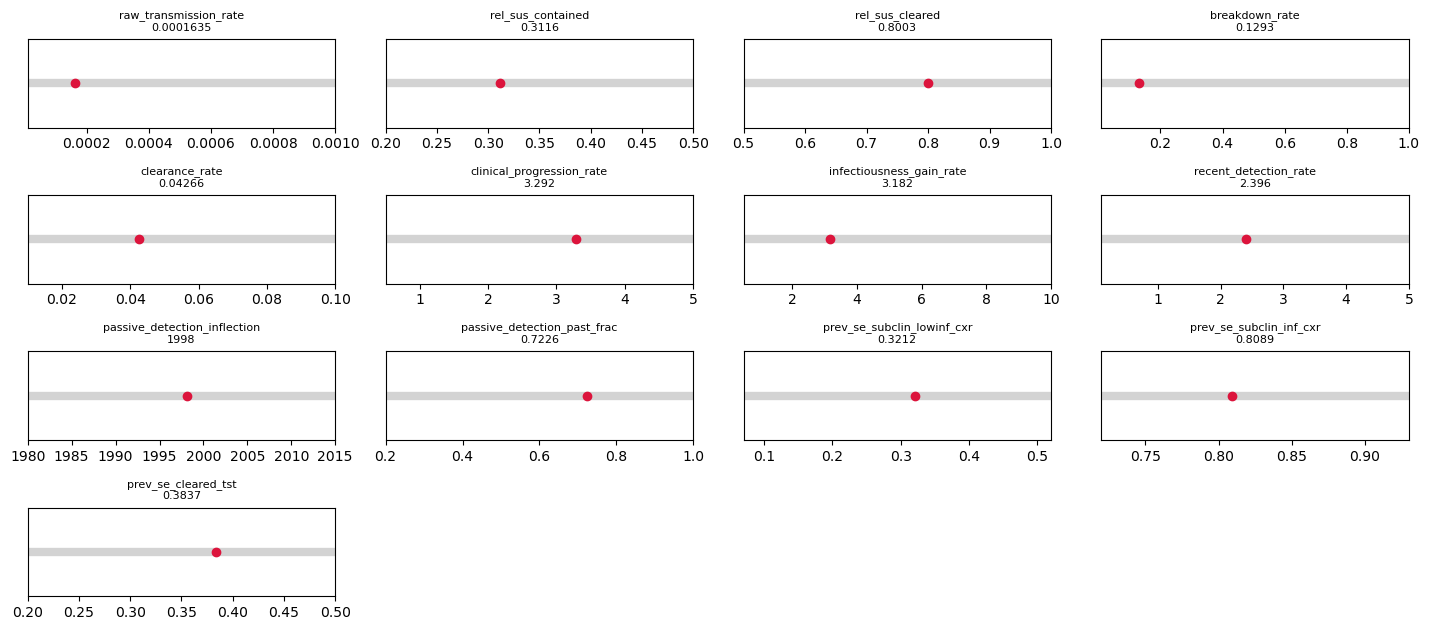

In [5]:
# parameters pinned against the edge of their prior range may indicate an over-constrained model
pl.visualise_mle_params(bcm.priors, mle_params);


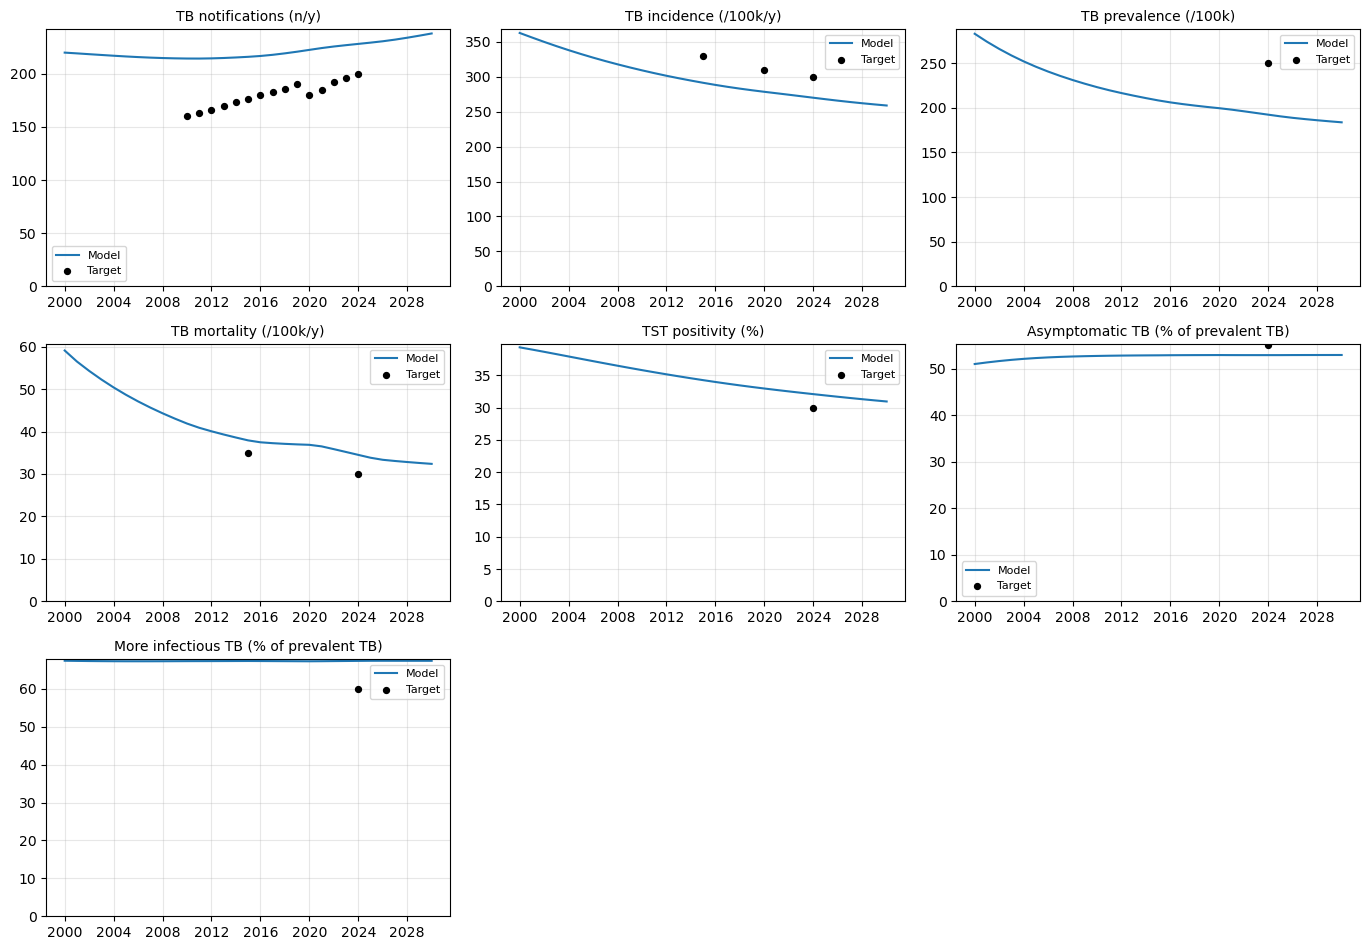

In [6]:
pl.plot_single_fit(bcm, mle_params, x_lim=(2000, 2030));


## 3. Metropolis sampling

The posterior is sampled with `DEMetropolisZ`, starting every chain from the MLE. The resulting
`InferenceData` object is saved so that the uncertainty around the baseline can be examined without
recalibrating.


In [7]:
t0 = time()
idata = rt.run_metropolis_calibration(
    bcm,
    draws=analysis_config["draws"],
    tune=analysis_config["tune"],
    cores=analysis_config["cores"],
    chains=analysis_config["chains"],
    initvals=[mle_params] * analysis_config["chains"],
)
print(f"Sampling completed in {round(time() - t0)} sec")


ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding
ERROR (pytensor.graph.rewriting.basic): node: Elemwise{Cast{float64}}(TensorConstant{2})
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1918, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1078, in transform
    return self.fn(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/tensor/rewriting/basic.py", line 1138, in constant_folding
    thunk = node.op.make_thunk(node, storage_map, compute_map, no_recycling=[])
  File "/User


You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_m4ijzhxm

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_ad9h3h8b

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_rzcxd4wd


ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding
ERROR (pytensor.graph.rewriting.basic): node: Elemwise{Cast{float64}}(TensorConstant{2})
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1918, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1078, in transform
    return self.fn(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/tensor/rewriting/basic.py", line 1138, in constant_folding
    thunk = node.op.make_thunk(node, storage_map, compute_map, no_recycling=[])
  File "/User


You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_zbms4qfw

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_it77oe0y

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_4gx7nops


ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding
ERROR (pytensor.graph.rewriting.basic): node: Elemwise{Cast{float64}}(TensorConstant{2})
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1918, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1078, in transform
    return self.fn(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/tensor/rewriting/basic.py", line 1138, in constant_folding
    thunk = node.op.make_thunk(node, storage_map, compute_map, no_recycling=[])
  File "/User

...

ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding
ERROR (pytensor.graph.rewriting.basic): node: Elemwise{Cast{float64}}(TensorConstant{2})
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1918, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1078, in transform
    return self.fn(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/tensor/rewriting/basic.py", line 1138, in constant_folding
    thunk = node.op.make_thunk(node, storage_map, compute_map, no_recycling=[])
  File "/User


You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_cngaoba7

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_ixv2y44h

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_g0tjm96c


ERROR (pytensor.graph.rewriting.basic): Rewrite failure due to: constant_folding
ERROR (pytensor.graph.rewriting.basic): node: Elemwise{Cast{float64}}(TensorConstant{2})
ERROR (pytensor.graph.rewriting.basic): TRACEBACK:
ERROR (pytensor.graph.rewriting.basic): Traceback (most recent call last):
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1918, in process_node
    replacements = node_rewriter.transform(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/graph/rewriting/basic.py", line 1078, in transform
    return self.fn(fgraph, node)
  File "/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/tensor/rewriting/basic.py", line 1138, in constant_folding
    thunk = node.op.make_thunk(node, storage_map, compute_map, no_recycling=[])
  File "/User


You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_e2ggsj7j

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_up2b6jnv

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_i4w6g2ub

You can find the C code in this temporary file: /var/folders/nc/fpbn40953196v_h_35rb1rwrnjtsfm/T/pytensor_compilation_error_40klbvsw


CompileError: Compilation failed (return status=1):
/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/bin/clang++ -dynamiclib -g -Wno-c++11-narrowing -fno-exceptions -fno-unwind-tables -fno-asynchronous-unwind-tables -DNPY_NO_DEPRECATED_API=NPY_1_7_API_VERSION -fPIC -undefined dynamic_lookup -I/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/numpy/core/include -I/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/include/python3.10 -I/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib/python3.10/site-packages/pytensor/link/c/c_code -L/Users/rrag0004/Documents/Code/tuberculosis_toy_model/.pixi/envs/default/lib -fvisibility=hidden -o /Users/rrag0004/.pytensor/compiledir_macOS-26.6.2-arm64-arm-64bit-arm-3.10.21-64/lazylinker_ext/lazylinker_ext.so /Users/rrag0004/.pytensor/compiledir_macOS-26.6.2-arm64-arm-64bit-arm-3.10.21-64/lazylinker_ext/mod.cpp
In file included fro

In [ ]:
output_dir = rt.create_output_dir("calibration")
az.to_netcdf(idata, output_dir / "idata.nc")
print(f"Saved to {output_dir / 'idata.nc'}")

burn_in = analysis_config["burn_in"]
burnt_idata = idata.sel(draw=range(burn_in, idata.sample_stats.sizes["draw"]))
az.summary(burnt_idata)


In [ ]:
# chains should be well mixed and indistinguishable from one another after burn-in
pl.plot_traces(idata, bcm, burn_in=burn_in);


In [ ]:
# blue: posterior density, black: prior density — a posterior matching its prior is uninformed by the data
pl.plot_post_prior_comparison(idata, priors, burn_in=burn_in);


## 4. Model fit with uncertainty

The model is rerun over a sample of the posterior, and the results are summarised as quantiles. This
is the same machinery the scenario notebooks use, applied here to the baseline scenario only.


In [ ]:
t0 = time()
full_runs, unc_dfs = rt.run_full_runs(
    {"baseline": bcm}, idata, burn_in, analysis_config["full_runs_samples"]
)
print(f"{analysis_config['full_runs_samples']} full runs completed in {round(time() - t0)} sec")

unc_df = unc_dfs["baseline"]
unc_df["tb_incidence_per100k"].loc[2020:2030]


In [ ]:
pl.plot_all_model_fits(unc_df, bcm, x_lim=(2000, 2030));


In [ ]:
# outputs that are not fitted to data, but inherit the calibration uncertainty
untargeted_outputs = ["population", "tb_treatment_starts", "n_on_treatment", "case_detection_prop"]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for ax, output in zip(axes.flatten(), untargeted_outputs):
    pl.plot_model_fit_with_uncertainty(ax, unc_df, output, x_lim=(2000, 2040))
    ax.set_title(pl.get_title(output), fontsize=10)
    ax.grid(alpha=0.3)
fig.tight_layout()


---

Two artefacts are now saved in `outputs/calibration/`:

* `mle_params.yml` — the best-fitting parameter set, used by notebooks 03 and 04 to compare
  scenarios on a single, common parameterisation;
* `idata.nc` — the full posterior, available for uncertainty analyses such as the one above.
